In [1]:
# load modules and define path
import pandas as pd
from scipy.io import arff
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import shap

PATH = 'speeddating.arff'

c:\Users\zitag\venvs\ML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data preparation


In [2]:
# view data
arff_file = arff.loadarff(PATH)
df = pd.DataFrame(arff_file[0])
df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,b'0',1.0,b'female',21.0,27.0,6.0,b'[4-6]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'0',b'0'
1,b'0',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,5.0,b'[6-8]',b'[5-6]',1.0,b'1',b'0',b'0'
2,b'1',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'Asian/Pacific Islander/Asian-American',b'1',...,b'[0-3]',b'[3-5]',7.0,NaN,b'[6-8]',b'[0-4]',1.0,b'1',b'1',b'1'
3,b'0',1.0,b'female',21.0,23.0,2.0,b'[2-3]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'1',b'1'
4,b'0',1.0,b'female',21.0,24.0,3.0,b'[2-3]',b'Asian/Pacific Islander/Asian-American',b'Latino/Hispanic American',b'0',...,b'[0-3]',b'[3-5]',6.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'1',b'1'


In [3]:
print(list(df.columns))

['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o', 'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important', 'd_funny_important', 'd_ambtition_important', 'd_shared_interests_important', 'attractive', 'sincere', '

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 123 entries, has_null to match
dtypes: float64(59), object(64)
memory usage: 7.9+ MB


In [5]:
for col in df.columns:
    if df[col].dtype != "float64" :

        encode = OrdinalEncoder()
        encode.fit(df[[col]])

        df[col] = encode.fit_transform(df[[col]])
df.dropna(inplace = True)

In [6]:
# drop 'match' and 'decision_o' column
col_to_drop = ['match', 'decision_o', 'has_null', 'wave', 'expected_num_matches', 'd_expected_happy_with_sd_people', 'd_expected_num_matches', 'd_expected_num_interested_in_me', 'd_expected_num_matches', 'like', 'guess_prob_liked', 'd_like', 'd_guess_prob_liked', 'met']
df.drop(col_to_drop, axis=1, inplace=True)

In [7]:
print(len(df))
df.head()

1048


,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,importance_same_race,importance_same_religion,...,d_movies,d_concerts,d_music,d_shopping,d_yoga,interests_correlate,d_interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,decision
0,0.0,21.0,27.0,6.0,2.0,1.0,3.0,0.0,2.0,4.0,...,2.0,2.0,2.0,1.0,0.0,0.14,1.0,3.0,2.0,1.0
1,0.0,21.0,22.0,1.0,0.0,1.0,3.0,0.0,2.0,4.0,...,2.0,2.0,2.0,1.0,0.0,0.54,2.0,3.0,2.0,1.0
3,0.0,21.0,23.0,2.0,1.0,1.0,3.0,0.0,2.0,4.0,...,2.0,2.0,2.0,1.0,0.0,0.61,2.0,3.0,2.0,1.0
4,0.0,21.0,24.0,3.0,1.0,1.0,4.0,0.0,2.0,4.0,...,2.0,2.0,2.0,1.0,0.0,0.21,1.0,3.0,2.0,1.0
5,0.0,21.0,25.0,4.0,2.0,1.0,3.0,0.0,2.0,4.0,...,2.0,2.0,2.0,1.0,0.0,0.25,1.0,3.0,2.0,0.0


In [8]:
X = df.drop('decision', axis=1)
y = df['decision']

# scale the data, because the dataset contains features with different scales, which can negatively impact the performance of some machine learning algorithms.
scaler = StandardScaler()

# create seperate train sets, because the dataset only contains hereteosexual matches, which means that the personlized model will only be trained on men or women.
X_women = X[X['gender'] == 0]
X_women_scaled = scaler.fit_transform(X_women.drop('gender', axis=1))
y_women = y[X['gender'] == 0]
X_men = X[X['gender'] == 1]
X_men_scaled = scaler.fit_transform(X_men.drop('gender', axis=1))
y_men = y[X['gender'] == 1]

# drop gender
X_women.drop('gender', axis=1, inplace=True)
X_men.drop('gender', axis=1, inplace=True)  

In [9]:
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(X_women, y_women, test_size=0.2, random_state=42)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_men, y_men, test_size=0.2, random_state=42)
# create scaled versions (after train-test split to avoid data leakage)
X_w_train_scaled = scaler.fit_transform(X_w_train)
X_w_test_scaled = scaler.transform(X_w_test)
X_m_train_scaled = scaler.fit_transform(X_m_train)
X_m_test_scaled = scaler.transform(X_m_test)

print(len(X_w_train))

424


In [10]:
# create mini dataset to simulate the data size of the experiment we are going to do
X_w_train_mini = X_w_train[:60]
X_w_train_scaled_mini = X_w_train_scaled[:60]
y_w_train_mini = y_w_train[:60]

X_m_train_mini = X_m_train[:60]
X_m_train_scaled_mini = X_m_train_scaled[:60]
y_m_train_mini = y_m_train[:60]

## Training

- I don't expect shap explanation to be very insightful, because the data is from different participants (as there is no way to distinguish them). What we might see is that common dating preferences appear in the explanations.
- TODO: the number of features still need to be decreased, by manual selection.

In [11]:
X_train_sel = X_w_train_scaled_mini
y_train_sel = y_w_train_mini
X_test_sel = X_w_test_scaled
y_test_sel = y_w_test

The accuracy is: 0.7289719626168224


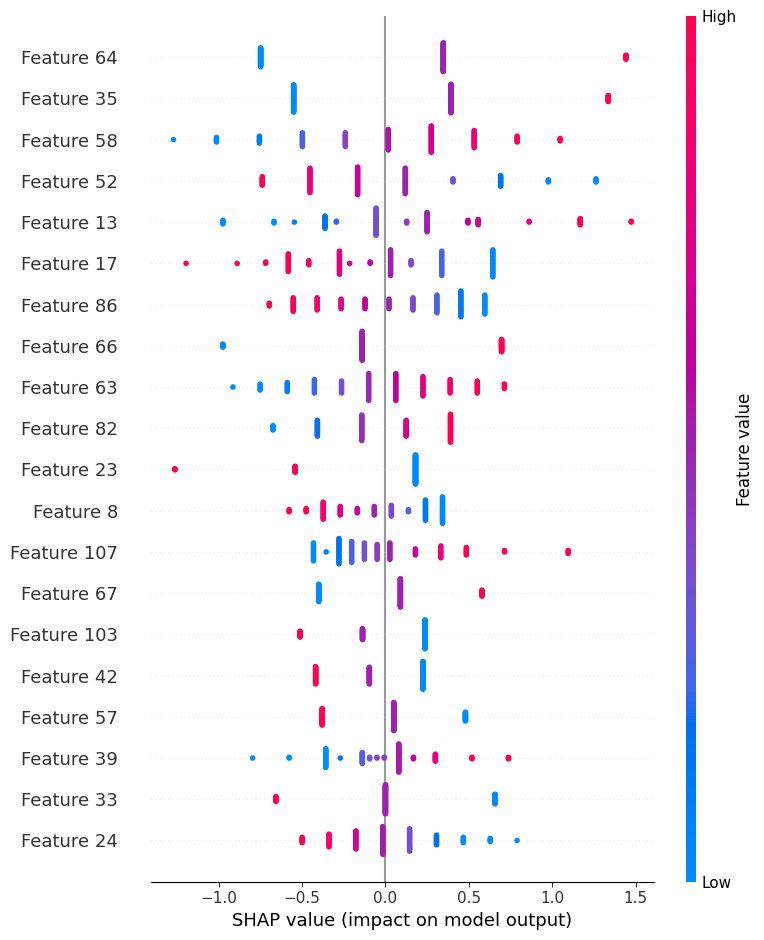

The accuracy of the explainer model is: 0.7289719626168224


In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)
model.fit(X_train_sel, y_train_sel)
accuracy = model.score(X_test_sel, y_test_sel)
print(f'The accuracy is: {accuracy}')

explainer = shap.Explainer(model, X_train_sel)
shap_values = explainer(X_test_sel)
# shap.waterfall_plot(shap_values[0])
shap.summary_plot(shap_values, X_test_sel)
print(f'The accuracy of the explainer model is: {accuracy}')

Coefficient for feature sincere_important: -0.06
Coefficient for feature intellicence_important: -0.13
Coefficient for feature funny_important: 0.27
Coefficient for feature ambtition_important: -0.09
Coefficient for feature shared_interests_important: -0.02


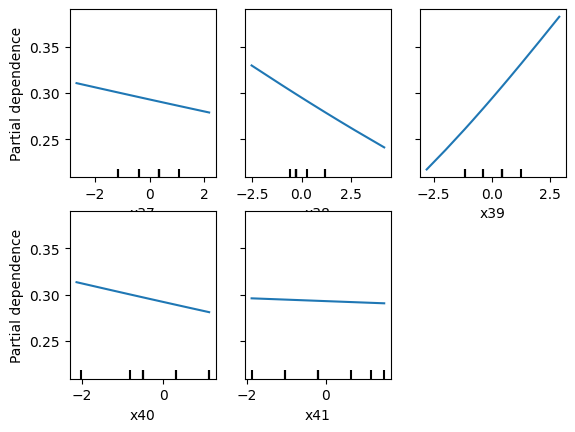

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
features = ['sincere_important',
            'intellicence_important',
            'funny_important',
            'ambtition_important',
            'shared_interests_important']
features_idx = [X_w_train.columns.get_loc(feature) for feature in features]   

PartialDependenceDisplay.from_estimator(model, X_test_sel, features_idx, kind='average')
# get the coefficients of feature_idx of the logistic regression model & print values
for idx in features_idx:
    print(f'Coefficient for feature {X_w_train.columns[idx]}: {model.coef_[0][idx]:.2f}')

The accuracy of decision tree is: 0.6261682242990654
intelligence_o: 0.04
funny_important: 0.04
d_funny_important: 0.10
attractive: 0.03
d_attractive_partner: 0.16
d_shared_interests_partner: 0.04
movies: 0.37
yoga: 0.15
interests_correlate: 0.07


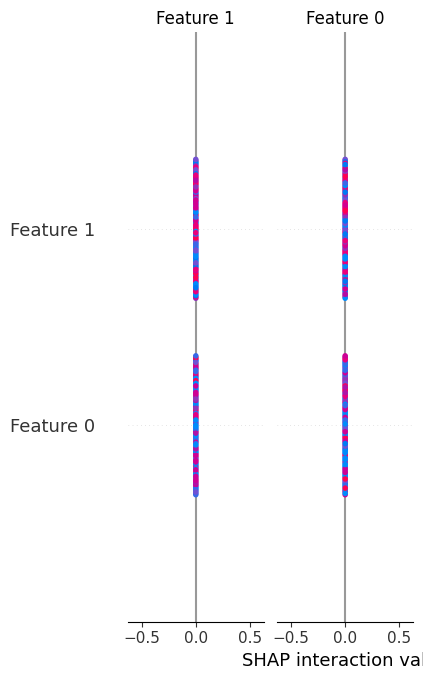

The accuracy of the explainer model is: 0.63


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_sel, y_train_sel)
accuracy_dt = model_dt.score(X_test_sel, y_test_sel)
print(f'The accuracy of decision tree is: {accuracy_dt:.3f}')

# print the feature importance of the decision tree model
feature_importance = model_dt.feature_importances_
if hasattr(X_train_sel, "columns"):
    feature_names = X_train_sel.columns
else:
    feature_names = X_w_train.columns  # feature order matches the NumPy array

for col, importance in zip(feature_names, feature_importance):
    if importance > 0:
        print(f"{col}: {importance:.2f}")

explainer = shap.Explainer(model_dt, X_train_sel)
shap_values = explainer(X_test_sel)
shap.summary_plot(shap_values, X_test_sel)
print(f'The accuracy of the explainer model is: {accuracy_dt:.3f}')

The accuracy of random forest is: 0.6822429906542056


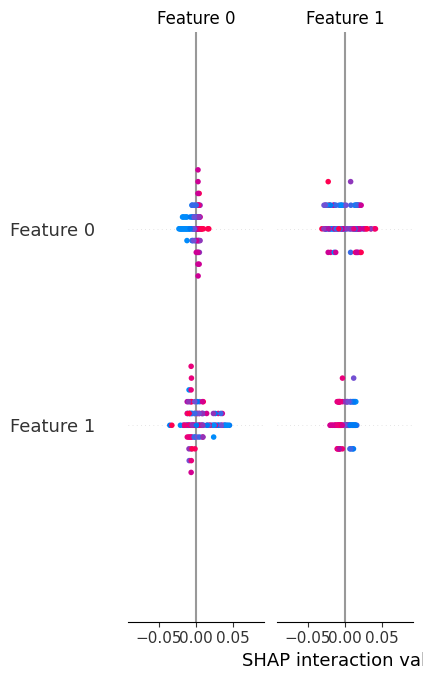

The accuracy of the explainer model is: 0.6822429906542056


In [ ]:
# random forest
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_sel, y_train_sel)
accuracy_rf = model_rf.score(X_test_sel, y_test_sel)
print(f'The accuracy of random forest is: {accuracy_rf:.3f}')

explainer = shap.Explainer(model_rf, X_train_sel,)
shap_values = explainer(X_test_sel, check_additivity=False)
shap.summary_plot(shap_values, X_test_sel)
print(f'The accuracy of the explainer model is: {accuracy_rf:.3f}')

The accuracy of xgboost is: 0.6915887850467289


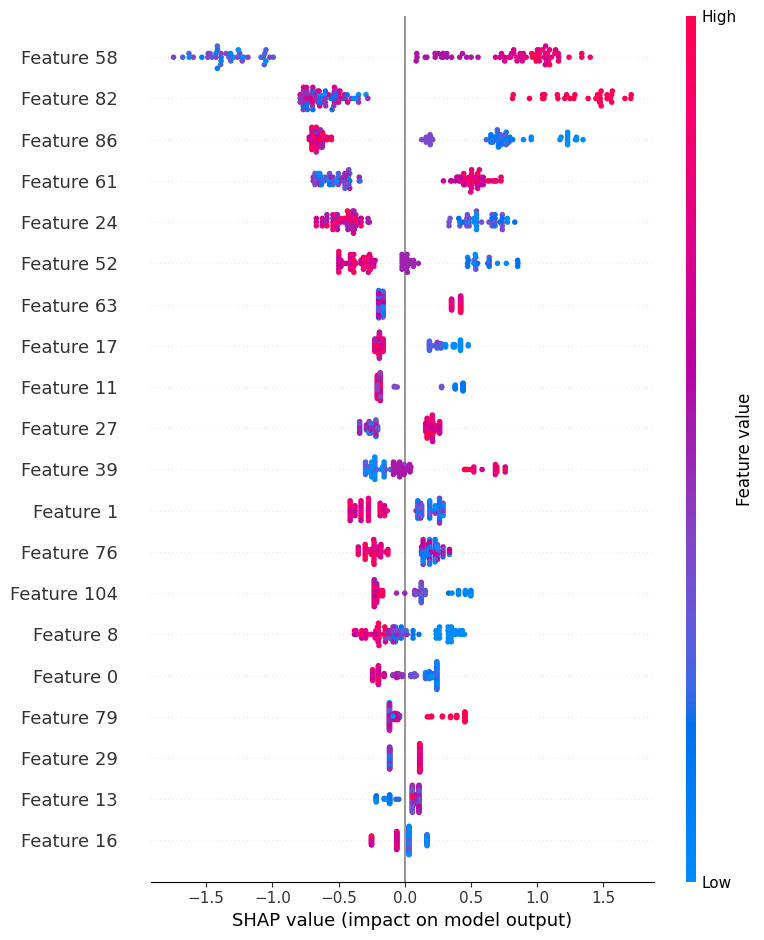

The accuracy of the explainer model is: 0.6915887850467289


In [ ]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42)
model_xgb.fit(X_train_sel, y_train_sel)
accuracy_xgb = model_xgb.score(X_test_sel, y_test_sel)
print(f'The accuracy of xgboost is: {accuracy_xgb:.3f}')

explainer = shap.Explainer(model_xgb, X_train_sel)
shap_values = explainer(X_test_sel)
shap.summary_plot(shap_values, X_test_sel)
print(f'The accuracy of the explainer model is: {accuracy_xgb:.3f}')

### Notes
*using `X_w_train_mini` / `X_w_train_scaled_mini` and `y_w_train_mini` of size 60* using standard scaling

**Logistic model**
- The SHAP explainer model and the logistic model have the exact same accuracy, which means that the SHAP model probably works the same as the logistic model, so the explanations must be accurate.
- This model performed the best out of all, given that we use `X_w_train_scaled_mini`

**Decision tree /  Random Forest**
- The decision tree / Random Forest model is too simple for the problem at hand. It does not allow for enough complexity to get a decent accuracy, given a small dataset. We should not use this model.
- The SHAP explanation is terrible because the model is too simple.

**XGBoost**
- Better than logistic model

**Other**
- For non-black-box models, model native explanation might be better. Like regularized coefficients from the logistic model.
- All models achieve higher accuracy given more data, so this might be an issue in our project. However, is all data is from the same person (with the same preferences) than we probably will get a higher accuracy with less data.
- Use waterfall (instead of summary) plots to visualize the SHAP explanation for a single prediction.
